In [162]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from scipy import stats
from Lasso import select_features_lasso
from sklearn.inspection import permutation_importance

In [163]:
df = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed']

In [164]:
cols_to_remove = ['BrO_Error', 'NO2_Error', 'O3_Error']
data = df.drop(columns = cols_to_remove)

In [165]:
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['target_precipitation'] = data['missforest_precipitation'].shift(-1)
data = data.dropna(subset=['target_precipitation'])

In [166]:
train_end = '2024-02-01'
val_end = '2025-02-01'

target_col = 'target_precipitation'
drop_cols = ['missforest_precipitation','observationTime', 't2m', target_col]

In [167]:
def metrics_fun(y_val, rf_pred_val):
    print(f'R^2:  {r2_score(y_val, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val, rf_pred_val))}')

    corr, p_value = stats.spearmanr(y_val, rf_pred_val)
    print(f"r_s:  {corr:.3f}")

In [168]:
def add_specific_lags(df):
    df = df.copy()

    df['seaLevelPressure_lag6'] = df['seaLevelPressure'].shift(6)
    df['xgb_cloudCover_lag6'] = df['xgb_cloudCover'].shift(6)
    df['airTemperature_lag6'] = df['airTemperature'].shift(6)
    df['relativeHumidity_lag_lag4'] = df['relativeHumidity'].shift(4)
    df['feelsLikeTemperature_fixed_lag3'] = df['feelsLikeTemperature_fixed'].shift(3)
    df['windSpeed_fixed_lag5'] = df['windSpeed_fixed'].shift(5)
    df['windGust_fixed_lag1'] = df['windGust_fixed'].shift(1)

    # df['windDirection_fixed_lag7'] = df['windDirection_fixed'].shift(7)

    
    return df

data_with_lags = add_specific_lags(data)
data_with_lags = data_with_lags.dropna().reset_index(drop=True)

original_pollutants = [
    'airTemperature',
    'relativeHumidity',
    'feelsLikeTemperature_fixed',
    'absorbing_aerosol_index',
    'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'BrO',
    'NO2',
    'O3',
    'pm10',
    'pm2p5',
    'sia',
    'nmvoc',
    'dust',
    'nh3',
    'pans',
    'airTemperature',
    'seaLevelPressure',
    'relativeHumidity',
    'xgb_cloudCover',
    'feelsLikeTemperature_fixed',
    'windSpeed_fixed',
    'windGust_fixed',
    # 'windDirection_fixed'
]

data_with_lags = data_with_lags.drop(columns=original_pollutants)

In [169]:
train = data_with_lags[data_with_lags['observationTime'] < train_end]
val   = data_with_lags[(data_with_lags['observationTime'] >= train_end) & (data_with_lags['observationTime'] <= val_end)]
test  = data_with_lags[data_with_lags['observationTime'] > val_end]

X_train = train.drop(columns=drop_cols)
y_train = train[target_col]

X_val = val.drop(columns=drop_cols)
y_val = val[target_col]

X_test = test.drop(columns=drop_cols)
y_test = test[target_col]

final_model = XGBRegressor(random_state=2026)
final_model.fit(X_train, y_train)

perm = permutation_importance(
    final_model, X_val, y_val,
    n_repeats=10,
    random_state=2026,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':    X_val.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

print("\nPermutation Importance:")
print(perm_df.to_string(index=False))

print("Val rezultatai:")
metrics_fun(y_val, final_model.predict(X_val))


Permutation Importance:
                        feature  importance      std
                             tp    1.149804 0.053509
            airTemperature_lag6    0.436836 0.060391
feelsLikeTemperature_fixed_lag3    0.382776 0.039200
          seaLevelPressure_lag6    0.094040 0.036297
      relativeHumidity_lag_lag4    0.084625 0.022671
                    day_of_year    0.061333 0.045693
           windSpeed_fixed_lag5    0.036425 0.036665
            windGust_fixed_lag1    0.030370 0.014915
            xgb_cloudCover_lag6    0.022175 0.017600
                          month    0.019559 0.005305
            windDirection_fixed   -0.009838 0.025669
                    day_of_week   -0.011889 0.016420
Val rezultatai:
R^2:  0.4987544892797605
MAE:  1.6526898485057726
RMSE: 3.4185747652523992
r_s:  0.576


In [170]:
tscv = TimeSeriesSplit(n_splits=5)

# param_grid = {
#     'n_estimators': [700, 750, 800, 850, 900],
#     'learning_rate': [0.001, 0.003, 0.005, 0.006, 0.01],
#     'max_depth': [2, 3, 4, 6],
#     'subsample': [0.5, 0.55, 0.6, 0.65, 0.7],
#     'min_split_loss':[14, 16, 18, 20]
# }

# param_grid = {
#     'n_estimators': [700, 800, 900, 1000, 1100, 1200],
#     'learning_rate': [0.003, 0.005, 0.006],
#     'max_depth': [4, 5, 6, 7, 8],
#     'subsample': [0.2, 0.3, 0.4],
#     'min_split_loss':[26, 28, 30, 32, 34, 36, 38]
# }

param_grid = {
    'n_estimators': [500, 550, 600, 650, 700],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=2026)

grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print(f"Geriausi parametrai: {grid_search.best_params_}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Geriausi parametrai: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 600, 'subsample': 1.0}


In [171]:
val_preds = model.predict(X_val)

mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2 = r2_score(y_val, val_preds)
corr, p_value = spearmanr(y_val, val_preds)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Spearmano koreliacijos koeficientas: {corr:.3f}")

MAE: 1.5597
RMSE: 3.6097
R2: 0.4411
Spearmano koreliacijos koeficientas: 0.688


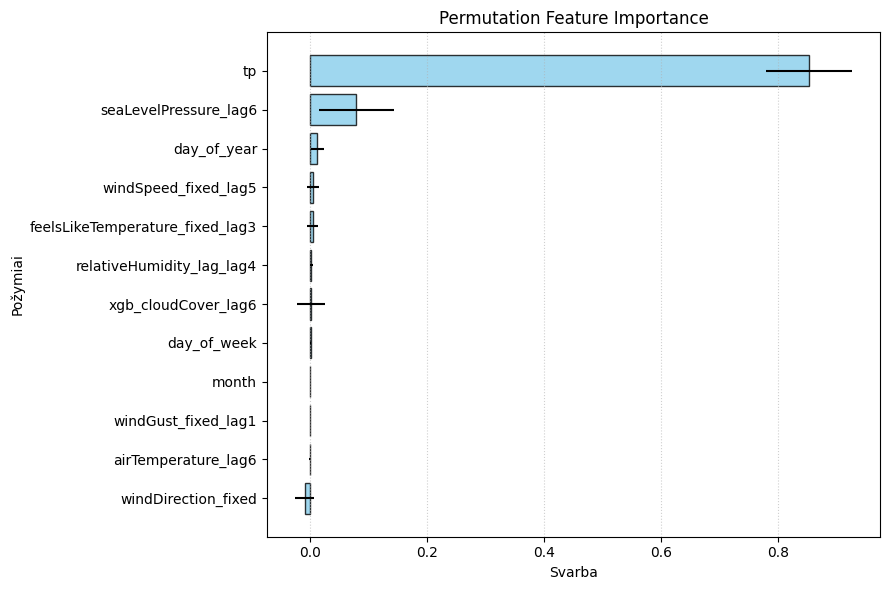


Požymių svarba:
                        Feature  Importance      Std
                             tp    0.852801 0.073232
          seaLevelPressure_lag6    0.079085 0.064453
                    day_of_year    0.012087 0.011441
           windSpeed_fixed_lag5    0.004662 0.010230
feelsLikeTemperature_fixed_lag3    0.003996 0.008902
      relativeHumidity_lag_lag4    0.002100 0.002559
            xgb_cloudCover_lag6    0.001281 0.024656
                    day_of_week    0.001006 0.000811
                          month    0.000000 0.000000
            windGust_fixed_lag1   -0.000220 0.000181
            airTemperature_lag6   -0.000786 0.001073
            windDirection_fixed   -0.009545 0.016830


In [172]:
result = permutation_importance(
    model, X_val, y_val, 
    scoring='r2', 
    n_repeats=10,
    random_state=2026
)

importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=True) 

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         xerr=importance_df['Std'], color='skyblue', edgecolor='black', alpha=0.8)

plt.xlabel('Svarba', fontsize=10)
plt.ylabel('Požymiai', fontsize=10)
plt.title('Permutation Feature Importance', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nPožymių svarba:")
print(importance_df.sort_values(by='Importance', ascending=False).to_string(index=False))

In [161]:
train_preds = model.predict(X_train).clip(min=0)
val_preds   = model.predict(X_val).clip(min=0)
test_preds  = model.predict(X_test).clip(min=0)

train_results = pd.DataFrame({
    'observationTime': train['observationTime'] + pd.Timedelta(days=1),
    'actual': y_train,
    'xgb_predicted': model.predict(X_train),
})

val_results = pd.DataFrame({
    'observationTime': val['observationTime'] + pd.Timedelta(days=1),
    'actual': y_val,
    'xgb_predicted': val_preds,
})

test_results = pd.DataFrame({
    'observationTime': test['observationTime'] + pd.Timedelta(days=1),
    'actual': y_test,
    'xgb_predicted': test_preds,
})

all_results = pd.concat([train_results, val_results, test_results], ignore_index=True)
all_results.to_csv('xgboost_pred_no_pollution.csv', index=False)

print(all_results.head())

  observationTime  actual  xgb_predicted
0      2018-07-08     0.0       0.503422
1      2018-07-09     0.0       0.305401
2      2018-07-10     0.0       0.396395
3      2018-07-11     0.6       0.964347
4      2018-07-12     0.3       1.968365
